<a href="https://colab.research.google.com/github/Codemelia/ml_ca/blob/master/src/Chailee/mnist_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# 1. Import libraries
# testing
# =========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# =========================================
# 2. Load MNIST dataset
# =========================================

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


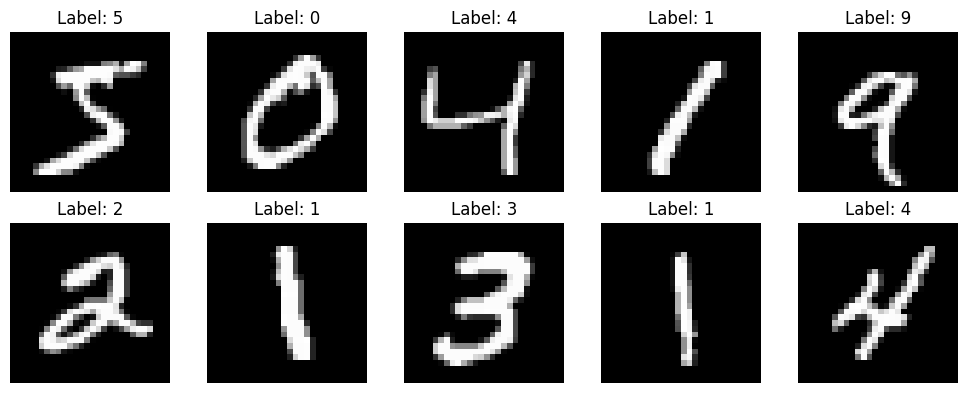

In [ ]:
# =========================================
# 3. Display sample images
# =========================================

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# 4. Preprocess the data
# =========================================
# Original pixel values are from 0 to 255.
# We normalize them to the range 0 to 1.

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
# CNN expects input shape:
# (number of samples, height, width, channels)
# -1 means Let NumPy calculate this dimension automatically.
# MNIST is grayscale, so channels = 1.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


In [ ]:
# =========================================
# 5. Build CNN model
# Architecture:
# Input(28x28x1)
# -> Conv1(16 filters)
# -> ReLU
# -> MaxPool(14x14)
# -> Conv2(32 filters)
# -> ReLU
# -> MaxPool(7x7)
# -> Flatten
# -> FC1(128)
# -> ReLU
# -> FC2(10 classes)
# =========================================

model = keras.Sequential([
    # Input layer
    keras.Input(shape=(28, 28, 1)),

    # Conv1: 16 filters, output shape: 28x28x16
    layers.Conv2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),

    # MaxPool: 28x28 -> 14x14
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Conv2: 32 filters, output shape: 14x14x32
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),

    # MaxPool: 14x14 -> 7x7
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten: 7x7x32 = 1568
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output layer
    # 10 neurons because MNIST has 10 classes: 0 to 9
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         200,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 206,922 (808.29 KB)

 Trainable params: 206,922 (808.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================
# 6. Compile the model
# =========================================
# Since labels are integers 0 to 9, use sparse_categorical_crossentropy.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# =========================================
# 7. Train the model
# 20% for validation
# 80% for training which is 48000, batch size is 32, so for each batch there is 48000/32=1500 samples
# =========================================

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9492 - loss: 0.1640 - val_accuracy: 0.9778 - val_loss: 0.0727
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9836 - loss: 0.0519 - val_accuracy: 0.9857 - val_loss: 0.0467
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9889 - loss: 0.0350 - val_accuracy: 0.9844 - val_loss: 0.0549
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9917 - loss: 0.0244 - val_accuracy: 0.9872 - val_loss: 0.0466
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9891 - val_loss: 0.0415
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9944 - loss: 0.0152 - val_accuracy: 0.9895 - val_loss: 0.0408
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9964 - loss: 0.0113 - val_accuracy: 0.9890 - val_loss: 0.0433
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9969 - loss: 0.0088 - 

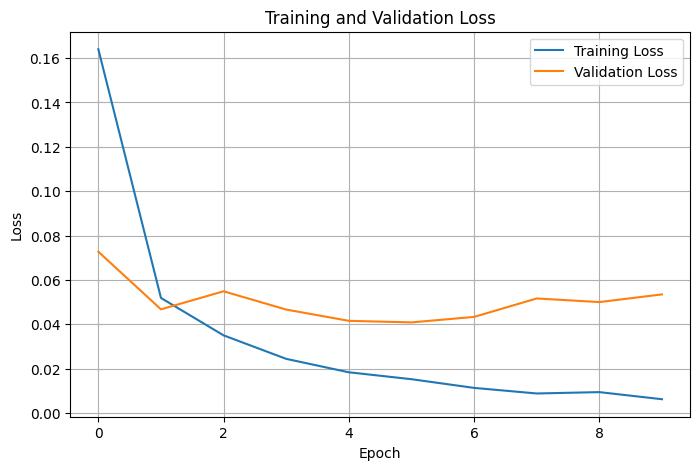

In [ ]:
# =========================================
# 8. Plot training and validation loss
# =========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

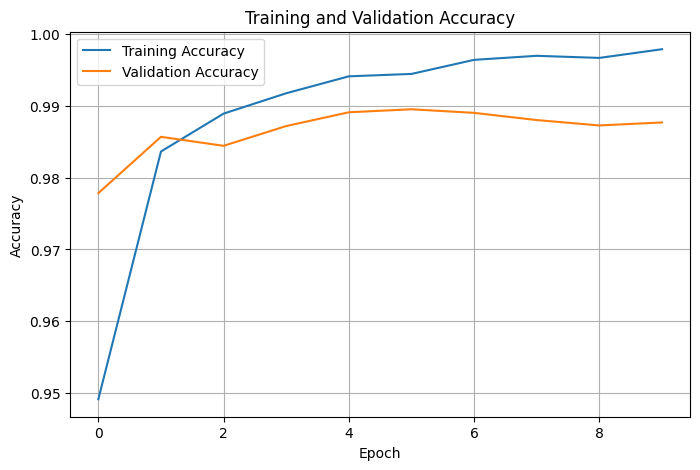

In [ ]:
# =========================================
# 9. Plot training and validation accuracy
# =========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================================
# 10. Evaluate the model on test data
# =========================================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9896 - loss: 0.0453
Test Loss: 0.04532860592007637
Test Accuracy: 0.9896000027656555


In [ ]:
# =========================================
# 11. Make predictions
# =========================================

y_pred_prob = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels:", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 10 predicted labels: [7 2 1 0 4 1 4 9 5 9]
First 10 true labels: [7 2 1 0 4 1 4 9 5 9]


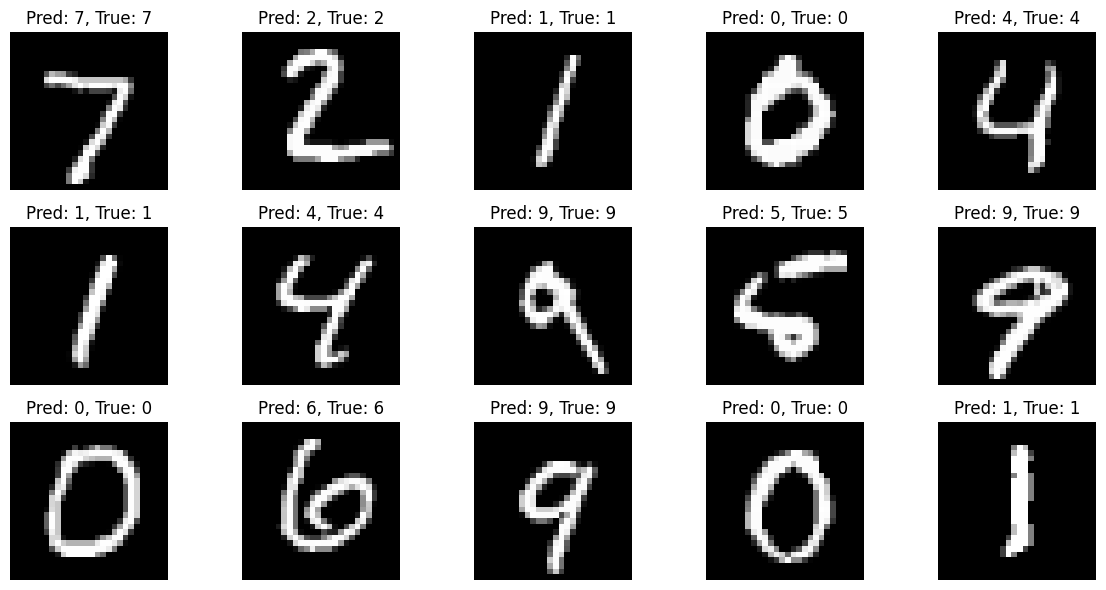

In [ ]:
# =========================================
# 12. Display sample predictions
# =========================================

plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}, True: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

the end